In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Conv1D, Flatten, concatenate, Dropout, Multiply, Lambda
from tensorflow.keras.layers import BatchNormalization, GlobalAveragePooling1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import pickle
import os
import time
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             roc_curve, precision_recall_curve, auc, accuracy_score)
from scipy.stats import ttest_rel
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Dense, LSTM, Conv1D, Flatten, concatenate, Dropout,
                                     Multiply, Reshape, BatchNormalization, GlobalAveragePooling1D,
                                     Lambda)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
# Load the Augmented dataset
df = pd.read_csv('CIC_IDS_2017_merged_filtered_data.csv')

# Selected features by IMOA
selected_features = [
    'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 
    'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Std', 
    'Bwd Packet Length Min', 'Bwd Packet Length Std', 'Flow IAT Std', 'Flow IAT Max', 
    'Flow IAT Min', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Mean', 'Bwd IAT Max', 
    'Bwd IAT Min', 'Fwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 
    'Bwd Packets/s', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Variance', 
    'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 
    'URG Flag Count', 'CWE Flag Count', 'Down/Up Ratio', 'Average Packet Size', 
    'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Subflow Fwd Packets', 
    'Subflow Bwd Packets', 'Subflow Bwd Bytes', 'Active Mean', 'Active Max', 
    'Active Min', 'Idle Std'
]

In [4]:
df.columns

Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Fwd URG Flags',
       ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s',
       ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length',
       ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance',
       'FIN Flag Count', ' SYN Flag Count', 

In [5]:
df.shape

(2836512, 71)

In [6]:
# Strip spaces from the column names in df
df.columns = df.columns.str.strip()

# Now you can select the features and label
X = df[selected_features].values
y = df['Label'].values  # Assuming 'Label' is the actual name after stripping

In [8]:
# Encode the labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_encoded = pd.get_dummies(y_encoded).values  # One-hot encode for multiclass classification

In [9]:
# Define CNN Model
def create_cnn_model(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(inputs)
    x = BatchNormalization()(x)
    x = GlobalAveragePooling1D()(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    output = Dense(num_classes, activation='softmax')(x)  # Output layer for multiclass classification
    model = Model(inputs, output)
    return model
# Define LSTM Model
def create_lstm_model(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    x = LSTM(64, return_sequences=True)(inputs)
    x = BatchNormalization()(x)
    x = LSTM(32)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    output = Dense(num_classes, activation='softmax')(x)  # Output layer for multiclass classification
    model = Model(inputs, output)
    return model
# Define FNN Model
def create_fnn_model(input_shape, num_classes):
    inputs = Input(shape=(input_shape,))
    x = Dense(128, activation='relu')(inputs)
    x = BatchNormalization()(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    output = Dense(num_classes, activation='softmax')(x)  # Output layer for multiclass classification
    model = Model(inputs, output)
    return model
# Define attention mechanism
def attention_mechanism(inputs):
    attention_weights = Dense(inputs.shape[-1], activation='softmax', name='attention_weights')(inputs)
    attention_output = Multiply(name='attention_output')([inputs, attention_weights])
    return attention_output, attention_weights



In [10]:
from memory_profiler import memory_usage

In [11]:
def train_ensemble():
    return ensemble_model.fit(
        [X_train_cnn, X_train_cnn, X_train], y_train,
        epochs=10,
        batch_size=128,
        validation_split=0.1,
        verbose=0,
        validation_data=([X_test_cnn, X_test_cnn, X_test], y_test)
    )

In [12]:
# Convert one-hot labels back to class labels for StratifiedKFold
y_labels = np.argmax(y_encoded, axis=1)
# --------------------------------- Part 4: 5-Fold Cross-Validation Setup ---------------------------------
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

ensemble_accs, cnn_accs, lstm_accs, fnn_accs = [], [], [], []
ensemble_times, cnn_times, lstm_times, fnn_times = [], [], [], []
ensemble_memory_usages, cnn_memory_usages, lstm_memory_usages, fnn_memory_usages = [], [], [], []
all_y_test = []
all_ensemble_pred = []
all_cnn_pred=[]
all_lstm_pred=[]
all_fnn_pred=[]
all_ensemble_prob = []
all_cm_ensemble = []
all_cm_cnn = []
all_cm_lstm = []
all_cm_fnn = []
attention_weights=[]
avg_atts=[]
fold = 1
for train_idx, test_idx in kfold.split(X, y_labels):
    print(f"\n=== Fold {fold} ===")
    fold += 1

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

    X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
    X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)
    # Number of classes in the dataset
    num_classes = y_train.shape[1]
    # CNN
    cnn_model = create_cnn_model(X_train_cnn.shape[1:], num_classes)
    cnn_model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    start = time.time()
    cnn_mem_usage, cnn_history = memory_usage(
    (cnn_model.fit, (X_train_cnn, y_train), {'epochs': 50, 'batch_size': 64, 'validation_split': 0.1, 'verbose': 0}),
    interval=0.1,
    retval=True )
    #cnn_history = cnn_model.fit(X_train_cnn, y_train, epochs=10, batch_size=64, validation_split=0.1, verbose=0)
    end = time.time()
    cnn_times.append(end - start)
    cnn_peak_memory = max(cnn_mem_usage)
    cnn_memory_usages.append(cnn_peak_memory)
    cnn_pred = (cnn_model.predict(X_test_cnn,verbose=0) > 0.5).astype(int)
    cnn_accs.append(accuracy_score(y_test, cnn_pred))
    
    # LSTM
  
    lstm_model = create_lstm_model(X_train_cnn.shape[1:], num_classes)
    lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    start = time.time()
    lstm_mem_usage, lstm_history = memory_usage(
    (lstm_model.fit, (X_train_cnn, y_train), {'epochs': 50, 'batch_size': 64, 'validation_split': 0.1, 'verbose': 0}),
     interval=0.1,retval=True)
    #lstm_history= lstm_model.fit(X_train_cnn, y_train, epochs=10, batch_size=64, validation_split=0.1, verbose=0)
    end = time.time()
    lstm_times.append(end - start)
    lstm_peak_memory = max(lstm_mem_usage)
    lstm_memory_usages.append(lstm_peak_memory)
    lstm_pred = (lstm_model.predict(X_test_cnn,verbose=0) > 0.5).astype(int)
    lstm_accs.append(accuracy_score(y_test, lstm_pred))
    
     # FNN
    
    fnn_model = create_fnn_model(X_train.shape[1], num_classes)
    fnn_model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    start = time.time()
    fnn_mem_usage, fnn_history = memory_usage(
    (fnn_model.fit, (X_train, y_train), {'epochs': 50, 'batch_size': 64, 'validation_split': 0.1, 'verbose': 0}),
    interval=0.1,
    retval=True)
    #fnn_history=fnn_model.fit(X_train, y_train, epochs=10, batch_size=64, validation_split=0.1, verbose=0)
    end = time.time()
    fnn_times.append(end - start)
    fnn_peak_memory = max(fnn_mem_usage)
    fnn_memory_usages.append(fnn_peak_memory)
    fnn_pred = (fnn_model.predict(X_test,verbose=0) > 0.5).astype(int)
    fnn_accs.append(accuracy_score(y_test, fnn_pred))
    
     # Ensemble
   
    # Get validation accuracy for dynamic weighting
    cnn_val_accuracy = cnn_model.evaluate(X_test_cnn, y_test, verbose=0)[1]
    lstm_val_accuracy = lstm_model.evaluate(X_test_cnn, y_test, verbose=0)[1]
    fnn_val_accuracy = fnn_model.evaluate(X_test, y_test, verbose=0)[1]
    
    # Calculate dynamic weights based on validation accuracy
    total_accuracy = cnn_val_accuracy + lstm_val_accuracy + fnn_val_accuracy
    weights = {
    'cnn': cnn_val_accuracy / total_accuracy,
    'lstm': lstm_val_accuracy / total_accuracy,
    'fnn': fnn_val_accuracy / total_accuracy
    }
    # Weighted outputs using Lambda layers
    cnn_weighted_output = Lambda(lambda x: x * weights['cnn'])(cnn_model.output)
    lstm_weighted_output = Lambda(lambda x: x * weights['lstm'])(lstm_model.output)
    fnn_weighted_output = Lambda(lambda x: x * weights['fnn'])(fnn_model.output)
    # Combine weighted outputs
    combined = concatenate([cnn_weighted_output, lstm_weighted_output, fnn_weighted_output], name='combined_features')
    # Apply attention mechanism on combined output
    attention_output, attention_tensor = attention_mechanism(combined)
    # Final output layer for multiclass classification
    output = Dense(num_classes, activation='softmax', name='output_layer')(attention_output)
    
    # Directly combine the model outputs without attention for testing
    combined = concatenate([cnn_weighted_output, lstm_weighted_output, fnn_weighted_output], name='combined_features')



   # Define the complete ensemble model
    ensemble_model = Model(inputs=[cnn_model.input, lstm_model.input, fnn_model.input], outputs=output)
    # This returns both the final classification output and attention weights
    ensemble_model_full = Model(inputs=[cnn_model.input, lstm_model.input, fnn_model.input],
                            outputs=[output, attention_tensor])

    # Compile and train the simplified model
    ensemble_model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    start = time.time()
    ensemble_mem_usage, ensemble_history = memory_usage(
    train_ensemble,interval=0.1,retval=True)
    #ensemble_history=ensemble_model.fit(
     #   [X_train_cnn, X_train_cnn, X_train], y_train,
       # validation_data=([X_test_cnn, X_test_cnn, X_test], y_test),
        #epochs=50, batch_size=128, verbose=0)
    ensemble_peak_memory = max(ensemble_mem_usage)
    ensemble_memory_usages.append(ensemble_peak_memory)
    end = time.time()
    ensemble_times.append(end - start)
    ensemble_output, att_weights = ensemble_model_full.predict([X_test_cnn, X_test_cnn, X_test], verbose=0)
    ensemble_pred = (ensemble_output > 0.5).astype(int)
   #ensemble_pred = (ensemble_model.predict([X_test_cnn, X_test_cnn, X_test],verbose=0) > 0.5).astype(int)
    ensemble_accs.append(accuracy_score(y_test, ensemble_pred))
    all_y_test.append(y_test)
    all_ensemble_pred.append(ensemble_pred)
    all_ensemble_prob.append(ensemble_model.predict([X_test_cnn, X_test_cnn, X_test],verbose=0))  # Probabilities for ROC/PR
    ensemble_probs, att_weights = ensemble_model_full.predict([X_test_cnn, X_test_cnn, X_test], verbose=0)
    attention_weights.append(att_weights)  # Now att_weights is a real NumPy array
    avg_atts.append(np.mean(att_weights, axis=0))  # Mean over all test samples
    y_pred_ensemble = ensemble_model.predict([X_test_cnn, X_test_cnn, X_test],verbose=0)
    y_pred_classes_ensemble = np.argmax(y_pred_ensemble, axis=1)
    y_true_classes = np.argmax(y_test, axis=1)
    cm_ensemble = confusion_matrix(y_true_classes, y_pred_classes_ensemble)
    all_cm_ensemble.append(cm_ensemble)
    y_pred_classes_cnn = np.argmax(cnn_pred, axis=1)
    cm_cnn=confusion_matrix(y_true_classes,  y_pred_classes_cnn)
    all_cm_cnn.append(cm_cnn)
    y_pred_classes_lstm = np.argmax(lstm_pred, axis=1)
    cm_lstm=confusion_matrix(y_true_classes,y_pred_classes_lstm)
    all_cm_lstm.append(cm_lstm)
    y_pred_classes_fnn = np.argmax(fnn_pred, axis=1)
    cm_fnn=confusion_matrix(y_true_classes,  y_pred_classes_fnn)
    all_cm_fnn.append(cm_fnn)
    


=== Fold 1 ===


=== Fold 2 ===

=== Fold 3 ===

=== Fold 4 ===

=== Fold 5 ===


In [91]:
# --------------------------------- Part 5: Report Results ---------------------------------
def report_scores(name, scores, times, memories):
    print(f"{name}: Accuracy = {np.mean(scores):.4f} ± {np.std(scores):.4f}, "
          f"Time = {np.mean(times):.2f}s ± {np.std(times):.2f}s, "
          f"Memory = {np.mean(memories):.2f} MiB ± {np.std(memories):.2f} MiB")

print("\n=== 5-Fold Cross-validation Results ===")
report_scores("CNN", cnn_accs, cnn_times, cnn_memory_usages)
report_scores("LSTM", lstm_accs, lstm_times, lstm_memory_usages)
report_scores("FNN", fnn_accs, fnn_times, fnn_memory_usages)
report_scores("Ensemble", ensemble_accs, ensemble_times, ensemble_memory_usages)


=== 5-Fold Cross-validation Results ===
CNN: Accuracy = 0.8685 ± 0.0029, Time = 26282.20s ± 479.48s, Memory = 1516.99 MiB ± 265.11 MiB
LSTM: Accuracy = 0.8733 ± 0.0419, Time = 227192.97s ± 169782.02s, Memory = 1563.88 MiB ± 254.57 MiB
FNN: Accuracy = 0.9412 ± 0.0105, Time = 8532.20s ± 785.83s, Memory = 1575.86 MiB ± 250.06 MiB
Ensemble: Accuracy = 0.9906 ± 0.0005, Time = 139234.90s ± 17927.13s, Memory = 1672.20 MiB ± 242.21 MiB


In [92]:

# --------------------------------- Part 6: Statistical Significance Testing ---------------------------------
print("\n=== Paired t-tests ===")
print("Ensemble vs CNN:", ttest_rel(ensemble_accs, cnn_accs))
print("Ensemble vs LSTM:", ttest_rel(ensemble_accs, lstm_accs))
print("Ensemble vs FNN:", ttest_rel(ensemble_accs, fnn_accs))


=== Paired t-tests ===
Ensemble vs CNN: TtestResult(statistic=83.06522046184398, pvalue=1.259084449585072e-07, df=4)
Ensemble vs LSTM: TtestResult(statistic=5.55420830644023, pvalue=0.005142676188209267, df=4)
Ensemble vs FNN: TtestResult(statistic=9.047216336434865, pvalue=0.0008270310181249053, df=4)


In [93]:
# Step 1: Define class labels
class_names = ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest',
               'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan',
               'SSH-Patator', 'Web Attack- Brute Force', 'Web Attack - Sql Injection', 
               'Web Attack - XSS']
xticklabels=class_names
yticklabels=class_names


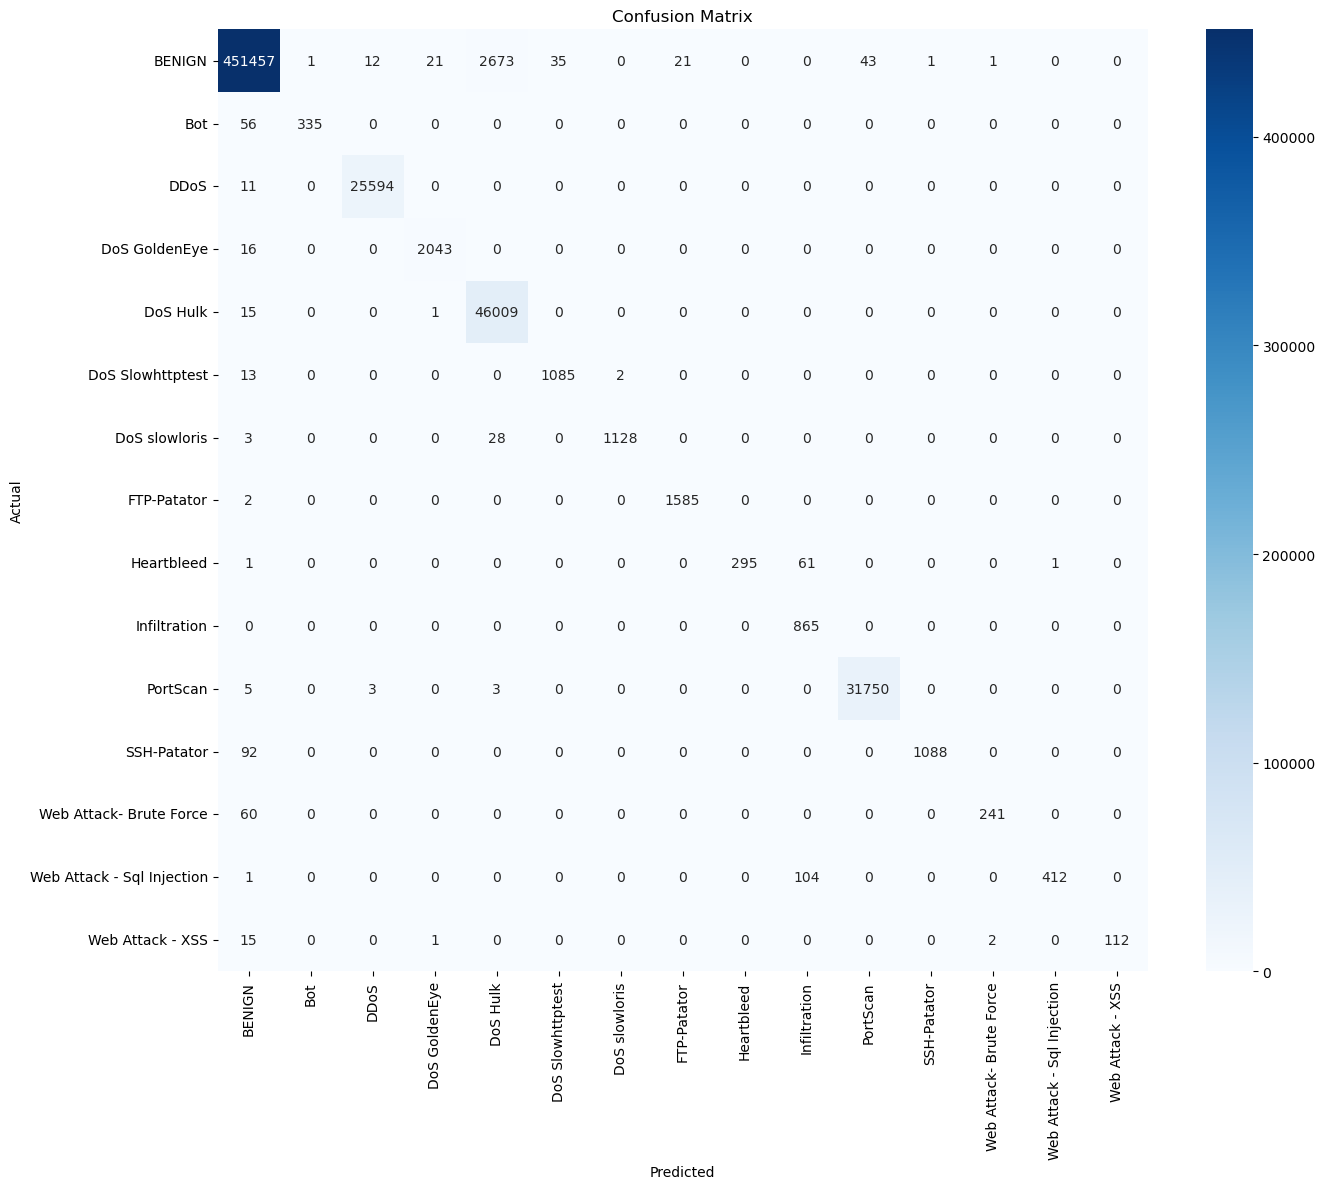

In [96]:
# Step 2: Compute average confusion matrix
avg_cm_ensemble = np.mean(all_cm_ensemble, axis=0).astype(int)

# Step 3: Plot using seaborn
plt.figure(figsize=(14, 12))
sns.heatmap(avg_cm_ensemble, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.title('Average Confusion Matrix - Ensemble Model (5-Fold CV)', fontsize=16)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('Peerj_revision1_CICIDS2017_multiclass_confusion_matrix.png', dpi=1200)
plt.show()




In [104]:
# Compute Classification report for Ensemble Model
from sklearn.metrics import classification_report

# Step 1: Define class labels
class_names = ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest',
               'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan',
              'SSH-Patator', 'Web Attack- Brute Force', 'Web Attack - Sql Injection', 
               'Web Attack - XSS']

# Step 2: Print classification report
report = classification_report(y_true_classes , y_pred_classes_ensemble, target_names=class_names)
print("Classification Report - Ensemble Model (5-Fold CV):CICIDS2017-Multiclass Classification")
print(report)



Classification Report - Ensemble Model (5-Fold CV):CICIDS2017-Multiclass Classification
                            precision    recall  f1-score   support

                    BENIGN       1.00      0.99      1.00   2271324
                       Bot       1.00      0.86      0.92      1955
                      DDoS       1.00      1.00      1.00    128024
             DoS GoldenEye       0.99      0.99      0.99     10295
                  DoS Hulk       0.94      1.00      0.97    230124
          DoS Slowhttptest       0.97      0.99      0.98      5500
             DoS slowloris       1.00      0.97      0.99      5795
               FTP-Patator       0.99      1.00      0.99      7935
                Heartbleed       1.00      0.82      0.90      1790
              Infiltration       0.84      1.00      0.91      4325
                  PortScan       1.00      1.00      1.00    158805
               SSH-Patator       1.00      0.92      0.96      5900
   Web Attack- Brute Force 

In [105]:
# Compute Classification report for CNN Model


# Step 1: Define class labels
class_names = ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest',
               'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan',
              'SSH-Patator', 'Web Attack- Brute Force', 'Web Attack - Sql Injection', 
               'Web Attack - XSS']

# Step 2: Print classification report
report = classification_report(y_true_classes , y_pred_classes_cnn, target_names=class_names)
print("Classification Report - CNN Model (5-Fold CV):CICIDS2017-Multiclass Classification")
print(report)



Classification Report - CNN Model (5-Fold CV):CICIDS2017-Multiclass Classification
                            precision    recall  f1-score   support

                    BENIGN       1.00      0.88      0.94   2271324
                       Bot       0.18      0.86      0.30      1955
                      DDoS       1.00      0.80      0.89    128024
             DoS GoldenEye       0.40      0.99      0.57     10295
                  DoS Hulk       0.93      0.83      0.88    230124
          DoS Slowhttptest       0.41      0.99      0.58      5500
             DoS slowloris       0.10      0.95      0.18      5795
               FTP-Patator       0.39      1.00      0.56      7935
                Heartbleed       0.03      0.82      0.06      1790
              Infiltration       0.07      1.00      0.13      4325
                  PortScan       0.92      0.75      0.83    158805
               SSH-Patator       1.00      0.92      0.96      5900
   Web Attack- Brute Force      

In [106]:
# Compute Classification report for LSTM Model
# Step 1: Define class labels
class_names = ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest',
               'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan',
              'SSH-Patator', 'Web Attack- Brute Force', 'Web Attack - Sql Injection', 
               'Web Attack - XSS']

# Step 2: Print classification report
report = classification_report(y_true_classes , y_pred_classes_lstm, target_names=class_names)
print("Classification Report - LSTM Model (5-Fold CV):CICIDS2017-Multiclass Classification")
print(report)


Classification Report - LSTM Model (5-Fold CV):CICIDS2017-Multiclass Classification
                            precision    recall  f1-score   support

                    BENIGN       1.00      0.88      0.94   2271324
                       Bot       0.09      0.86      0.16      1955
                      DDoS       1.00      0.73      0.84    128024
             DoS GoldenEye       0.34      0.99      0.50     10295
                  DoS Hulk       0.94      0.87      0.90    230124
          DoS Slowhttptest       0.23      0.99      0.38      5500
             DoS slowloris       0.10      0.95      0.18      5795
               FTP-Patator       0.75      1.00      0.86      7935
                Heartbleed       0.03      0.82      0.06      1790
              Infiltration       0.07      1.00      0.13      4325
                  PortScan       0.92      0.75      0.83    158805
               SSH-Patator       0.52      0.92      0.67      5900
   Web Attack- Brute Force     

In [107]:
# Compute Classification report for FNN Model
# Step 1: Define class labels
class_names = ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest',
               'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan',
              'SSH-Patator', 'Web Attack- Brute Force', 'Web Attack - Sql Injection', 
               'Web Attack - XSS']

# Step 2: Print classification report
report = classification_report(y_true_classes , y_pred_classes_fnn, target_names=class_names)
print("Classification Report - FNN Model (5-Fold CV):CICIDS2017-Multiclass Classification")
print(report)


Classification Report - FNN Model (5-Fold CV):CICIDS2017-Multiclass Classification
                            precision    recall  f1-score   support

                    BENIGN       1.00      0.95      0.97   2271324
                       Bot       0.99      0.86      0.92      1955
                      DDoS       1.00      0.92      0.96    128024
             DoS GoldenEye       0.40      0.99      0.57     10295
                  DoS Hulk       0.94      0.93      0.94    230124
          DoS Slowhttptest       0.97      0.99      0.98      5500
             DoS slowloris       0.10      0.95      0.18      5795
               FTP-Patator       0.75      1.00      0.86      7935
                Heartbleed       1.00      0.82      0.90      1790
              Infiltration       0.83      1.00      0.91      4325
                  PortScan       0.92      0.75      0.83    158805
               SSH-Patator       1.00      0.92      0.96      5900
   Web Attack- Brute Force      

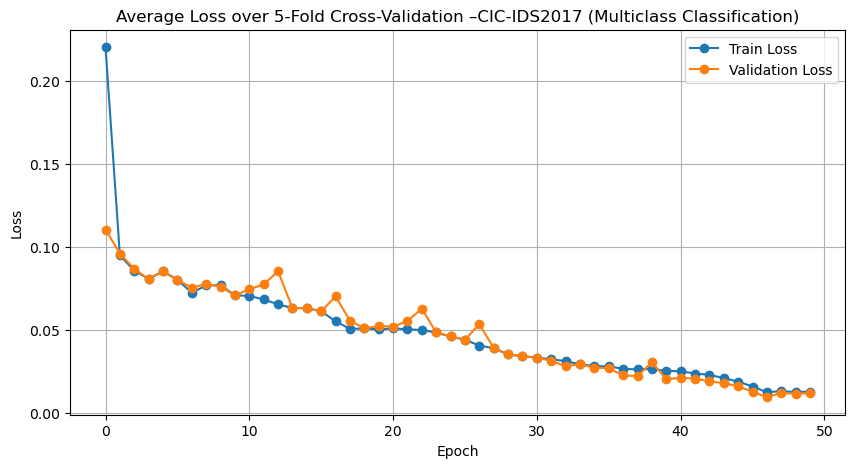

In [121]:
plt.figure(figsize=(10, 5))
plt.plot(ensemble_history.history['loss'], label='Train Loss', marker='o')
plt.plot(ensemble_history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Average Loss over 5-Fold Cross-Validation –CIC-IDS2017 (Multiclass Classification)')
plt.grid(True)
plt.savefig("peerj_revision1_CIC-IDS2017_loss_multiclass.png",dpi=1200)
plt.show()

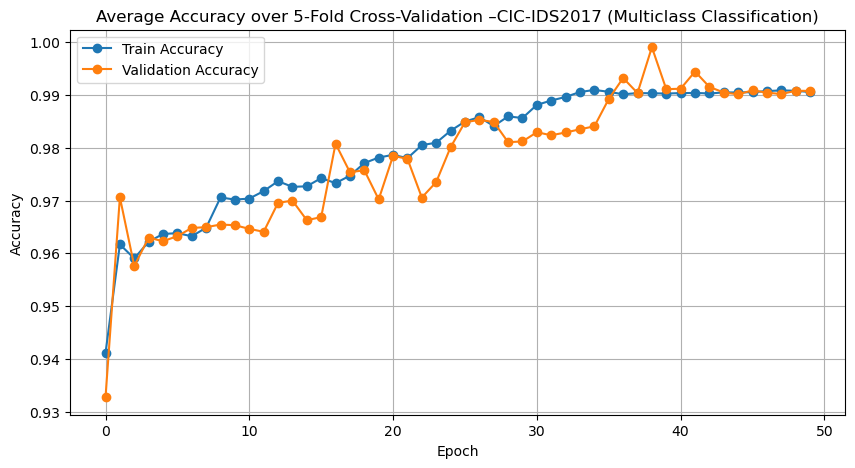

In [124]:
# Accuracy and loss plots
plt.figure(figsize=(10, 5))
plt.plot(ensemble_history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(ensemble_history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Average Accuracy over 5-Fold Cross-Validation –CIC-IDS2017 (Multiclass Classification)')
plt.grid(True)
plt.savefig("peerj_revision1_CIC-IDS2017_Accuracy_multiclass.png",dpi=1200)
plt.show()

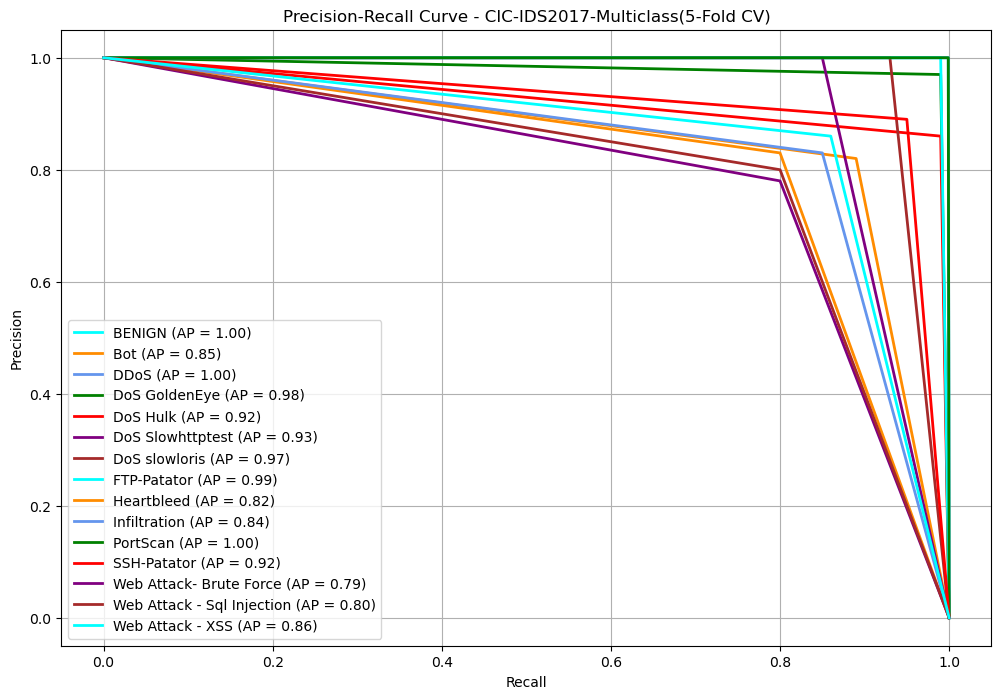

In [127]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Class names
class_names = ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest',
               'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan',
               'SSH-Patator', 'Web Attack- Brute Force', 'Web Attack - Sql Injection', 
               'Web Attack - XSS']

# Concatenate predictions and true labels across folds
y_true_all = np.concatenate(all_y_test, axis=0)
y_scores_all = np.concatenate(all_ensemble_prob, axis=0)

# Number of classes
n_classes = y_true_all.shape[1]

# Plot PR curve per class
plt.figure(figsize=(12, 8))
for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_true_all[:, i], y_scores_all[:, i])
    ap = average_precision_score(y_true_all[:, i], y_scores_all[:, i])
    plt.plot(recall, precision, lw=2, label=f'{class_names[i]} (AP={ap:.2f})')

# Final plot formatting
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - CIC-IDS2017-Multiclass(5-Fold CV)')
plt.legend(loc='lower left')
plt.grid(True)
plt.savefig("Peerj_revision1_PR_Curve_CIC-IDS2017_Multiclass.png",dpi=1200)
plt.show()

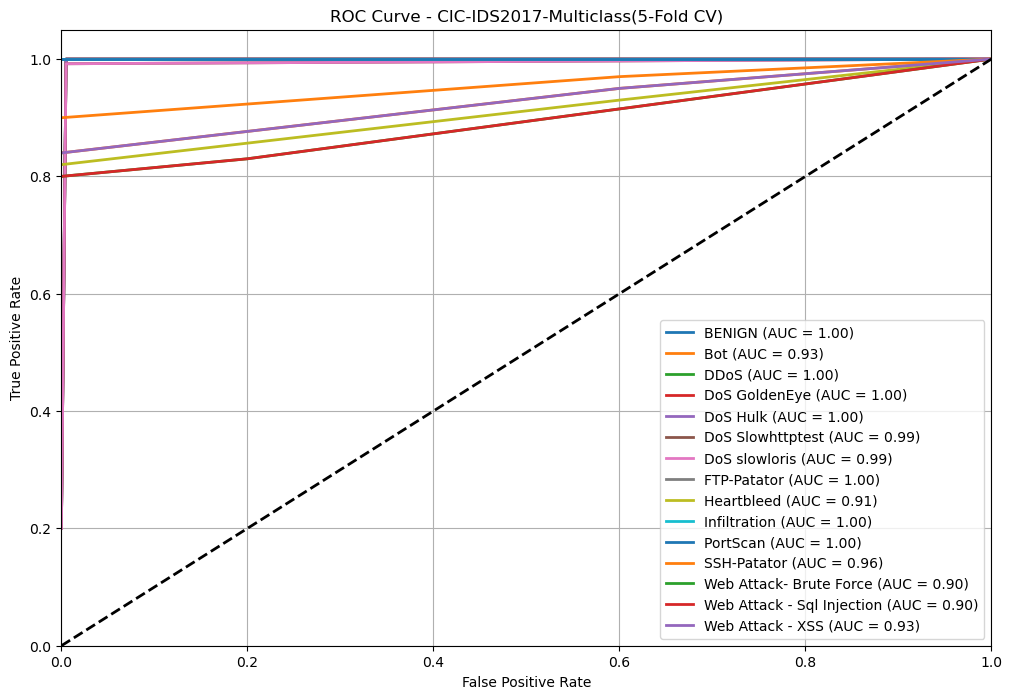

In [131]:
from sklearn.metrics import roc_curve, auc
# Concatenate across folds
y_true_all = np.concatenate(all_y_test, axis=0)
y_scores_all = np.concatenate(all_ensemble_prob, axis=0)
n_classes = y_true_all.shape[1]

# Plot ROC curve per class
plt.figure(figsize=(12, 8))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_all[:, i], y_scores_all[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{class_names[i]} (AUC={roc_auc:.2f})')

# Plot settings
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - CIC-IDS2017-Multiclass(5-Fold CV)')
plt.legend(loc='lower right')
plt.grid(True)
plt.savefig("Peerj_revision1_ROC_Curve_CIC-IDS2017_Multiclass.png",dpi=1200)
plt.show()


In [142]:
selected_feature_number = np.array([selected_features])

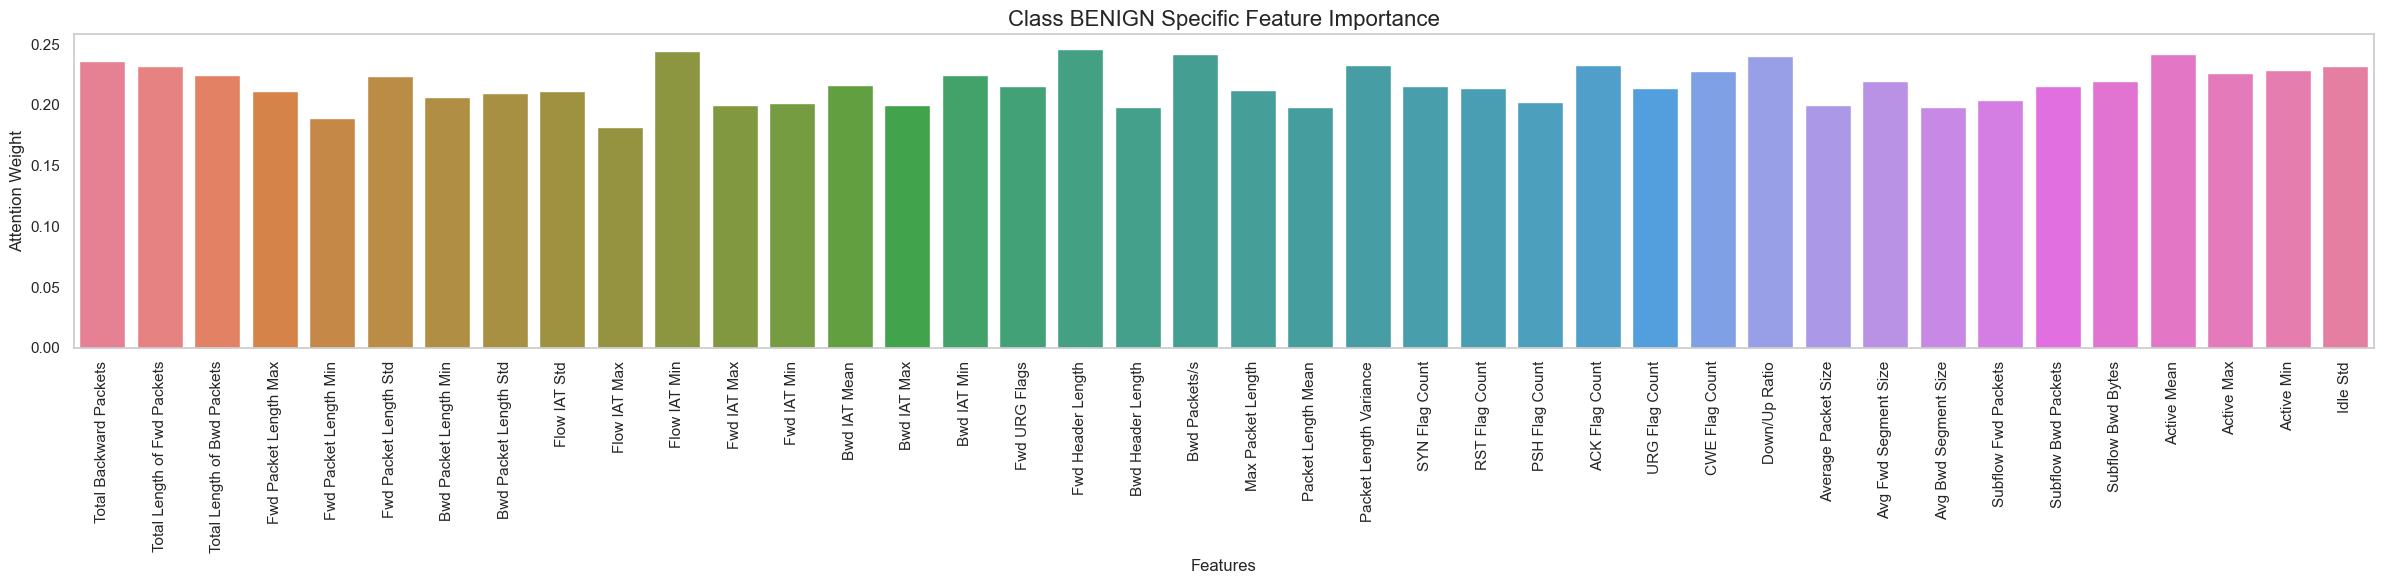

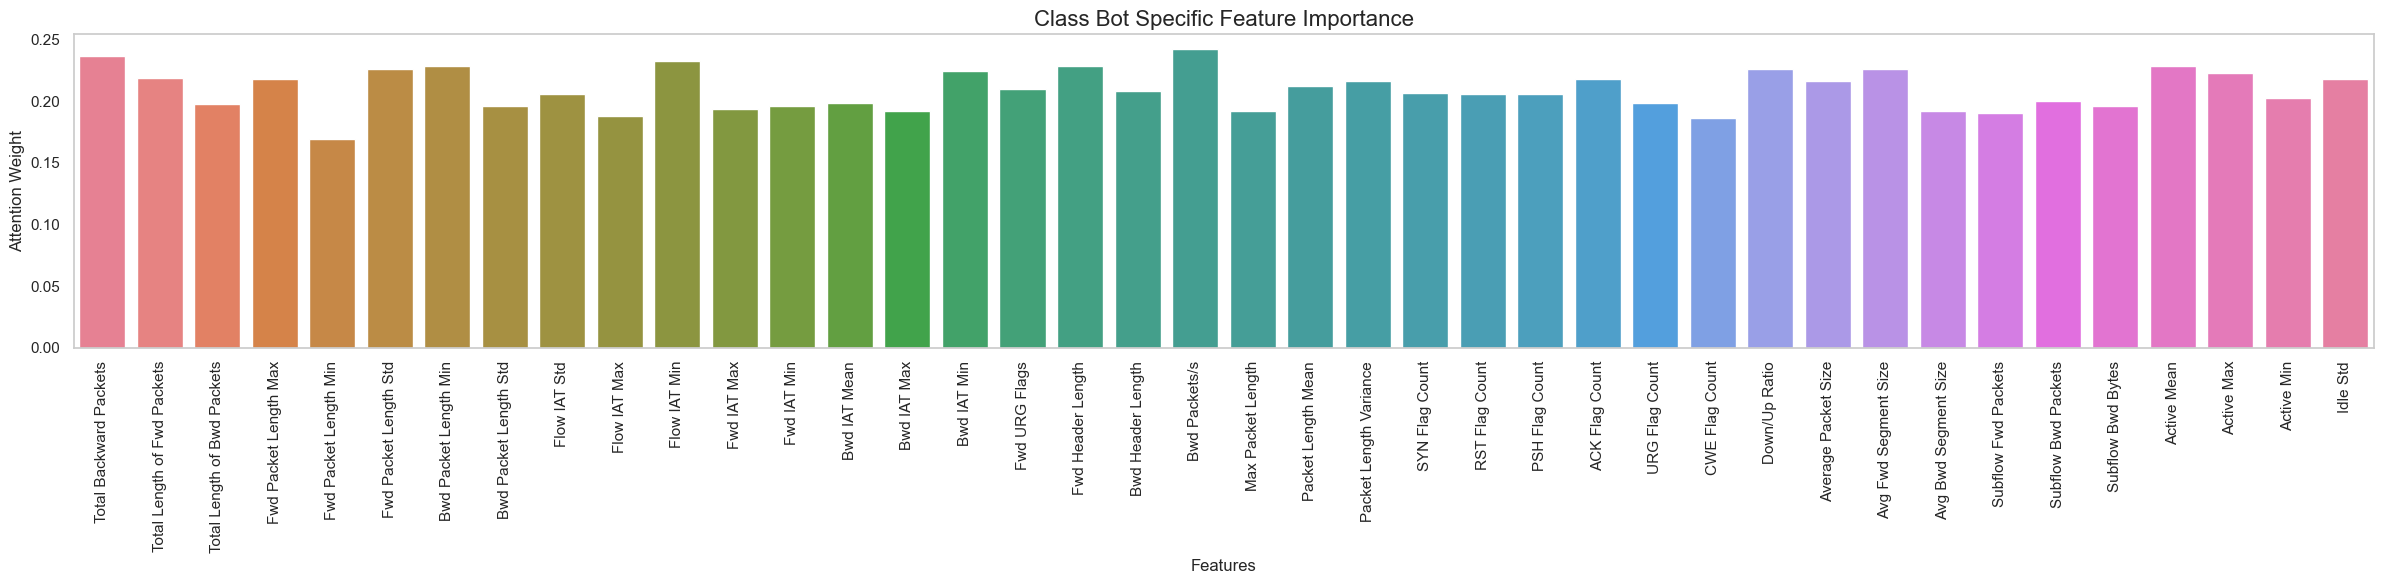

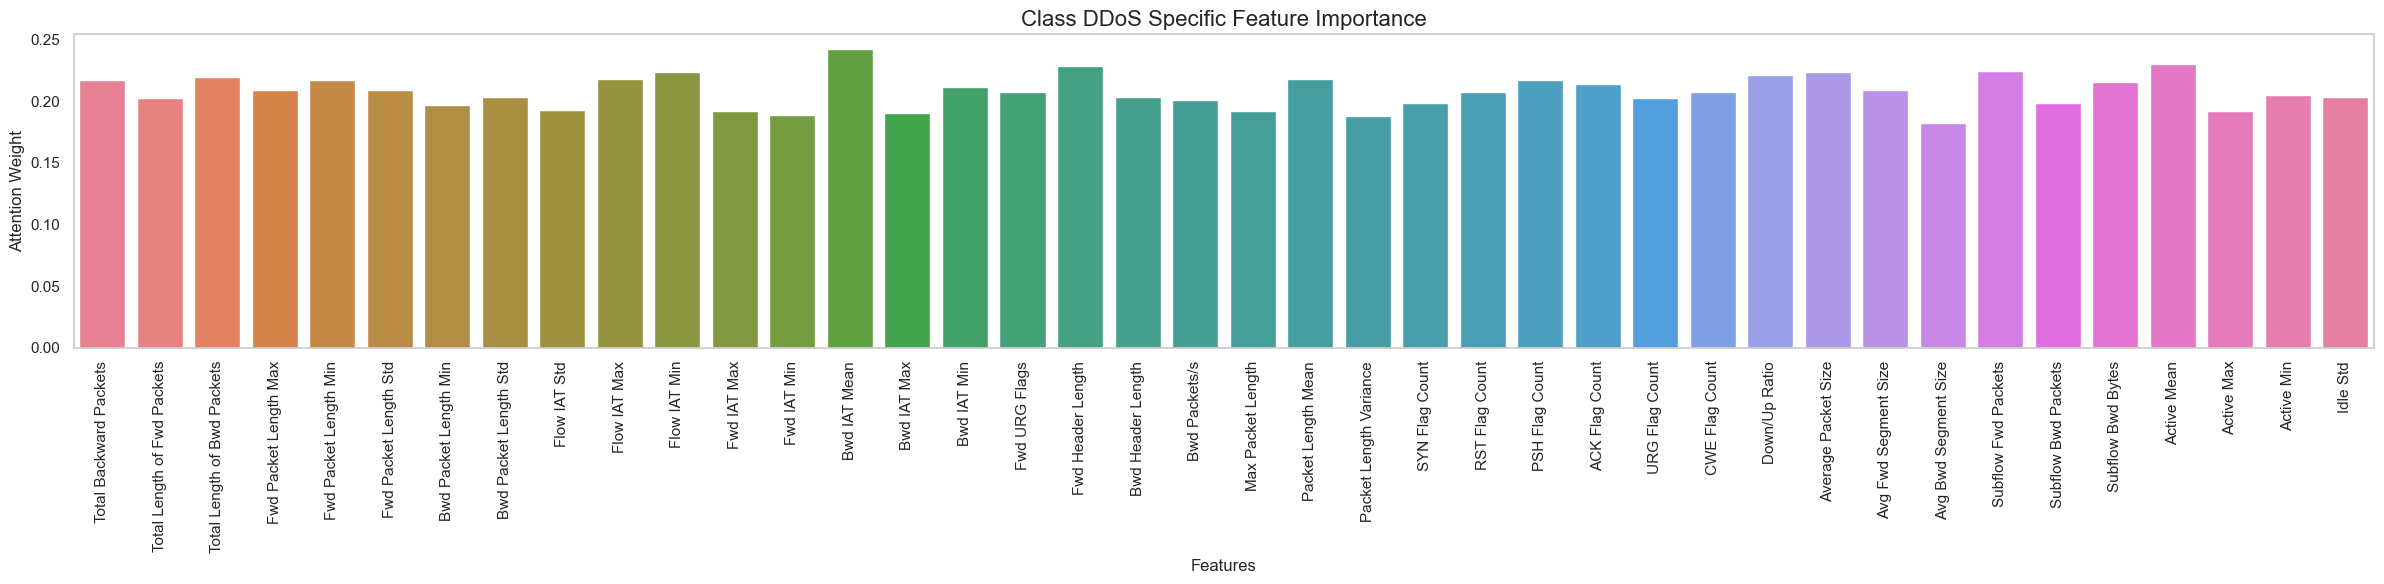

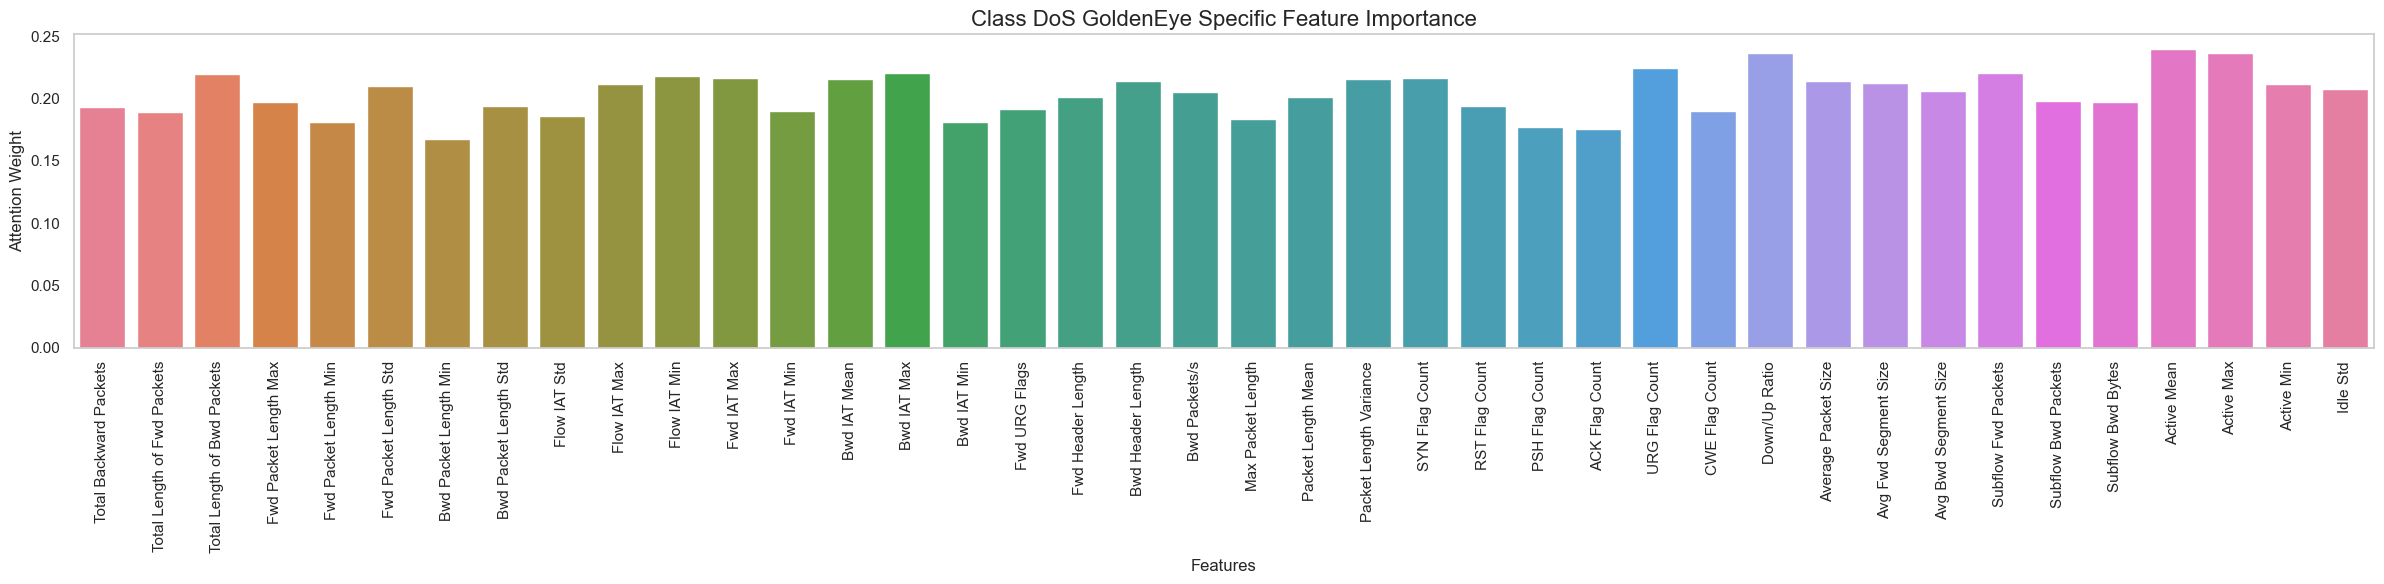

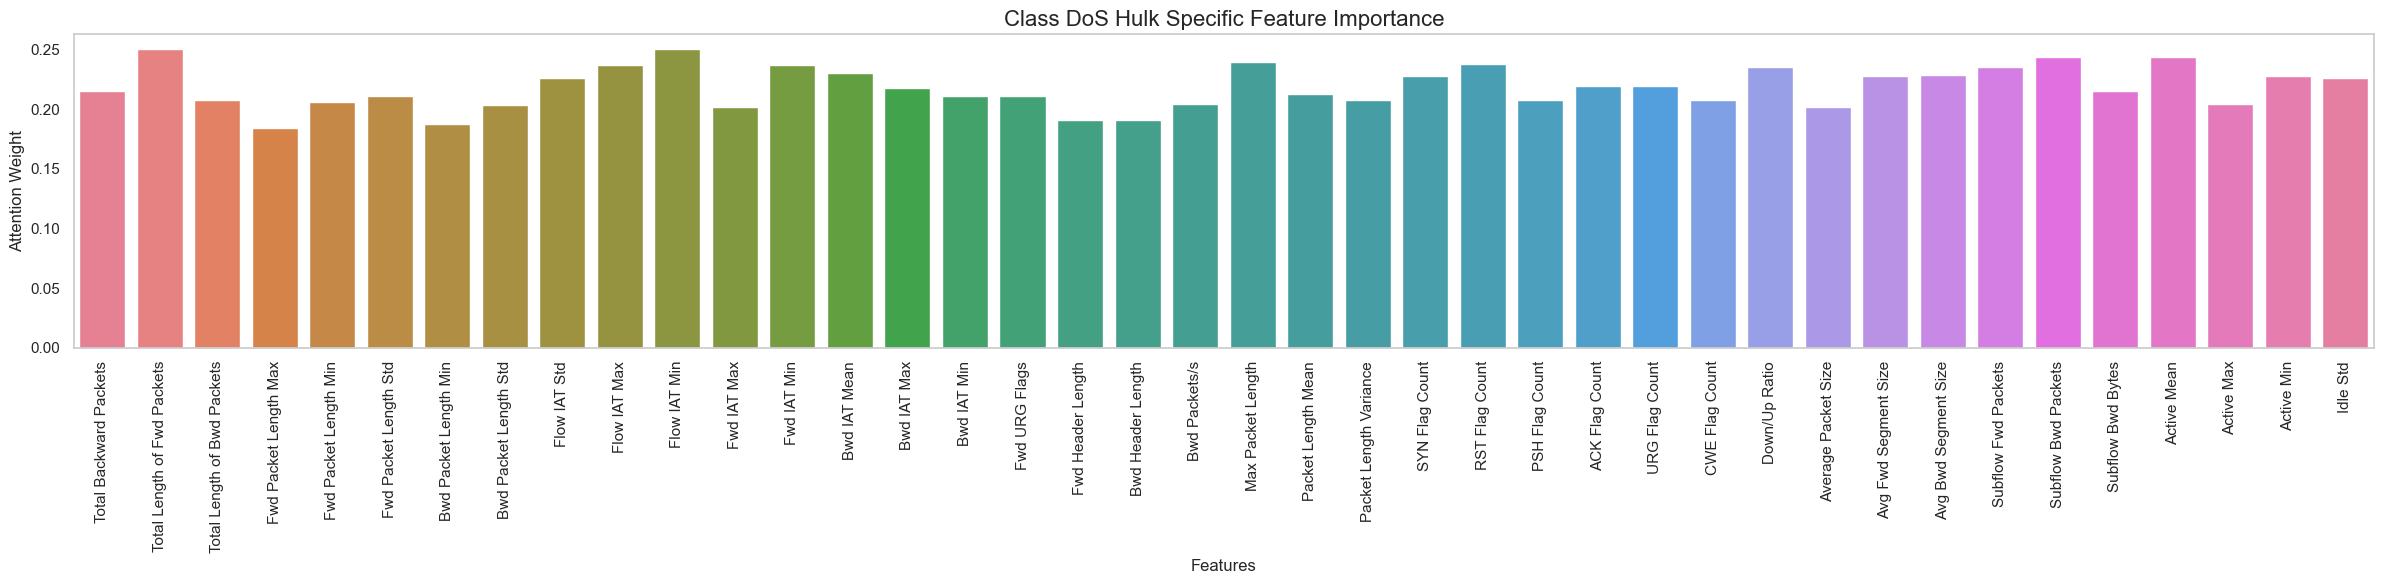

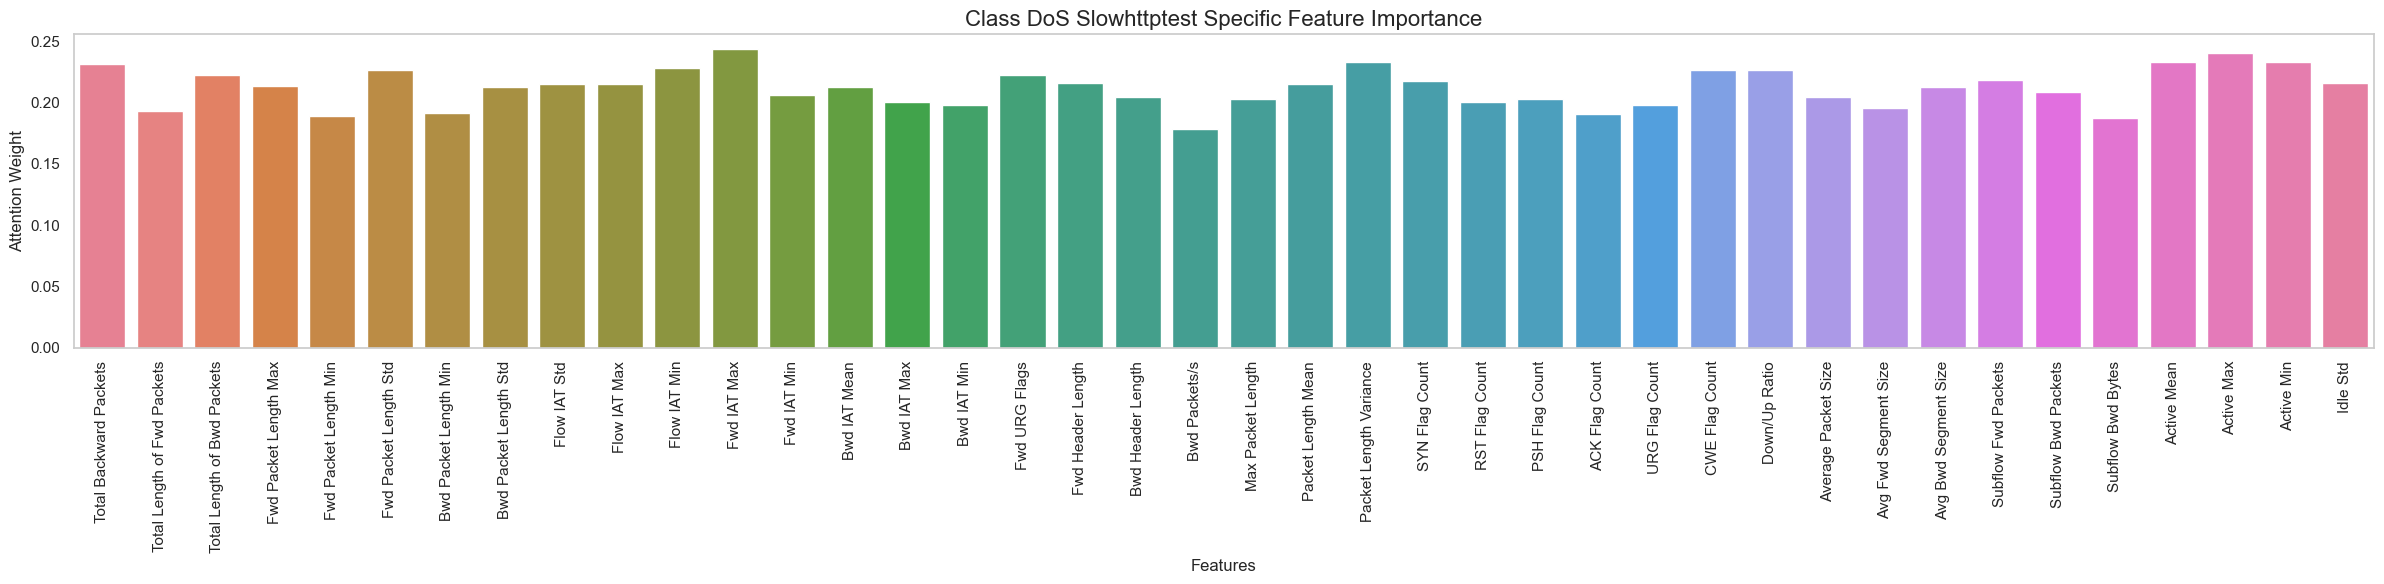

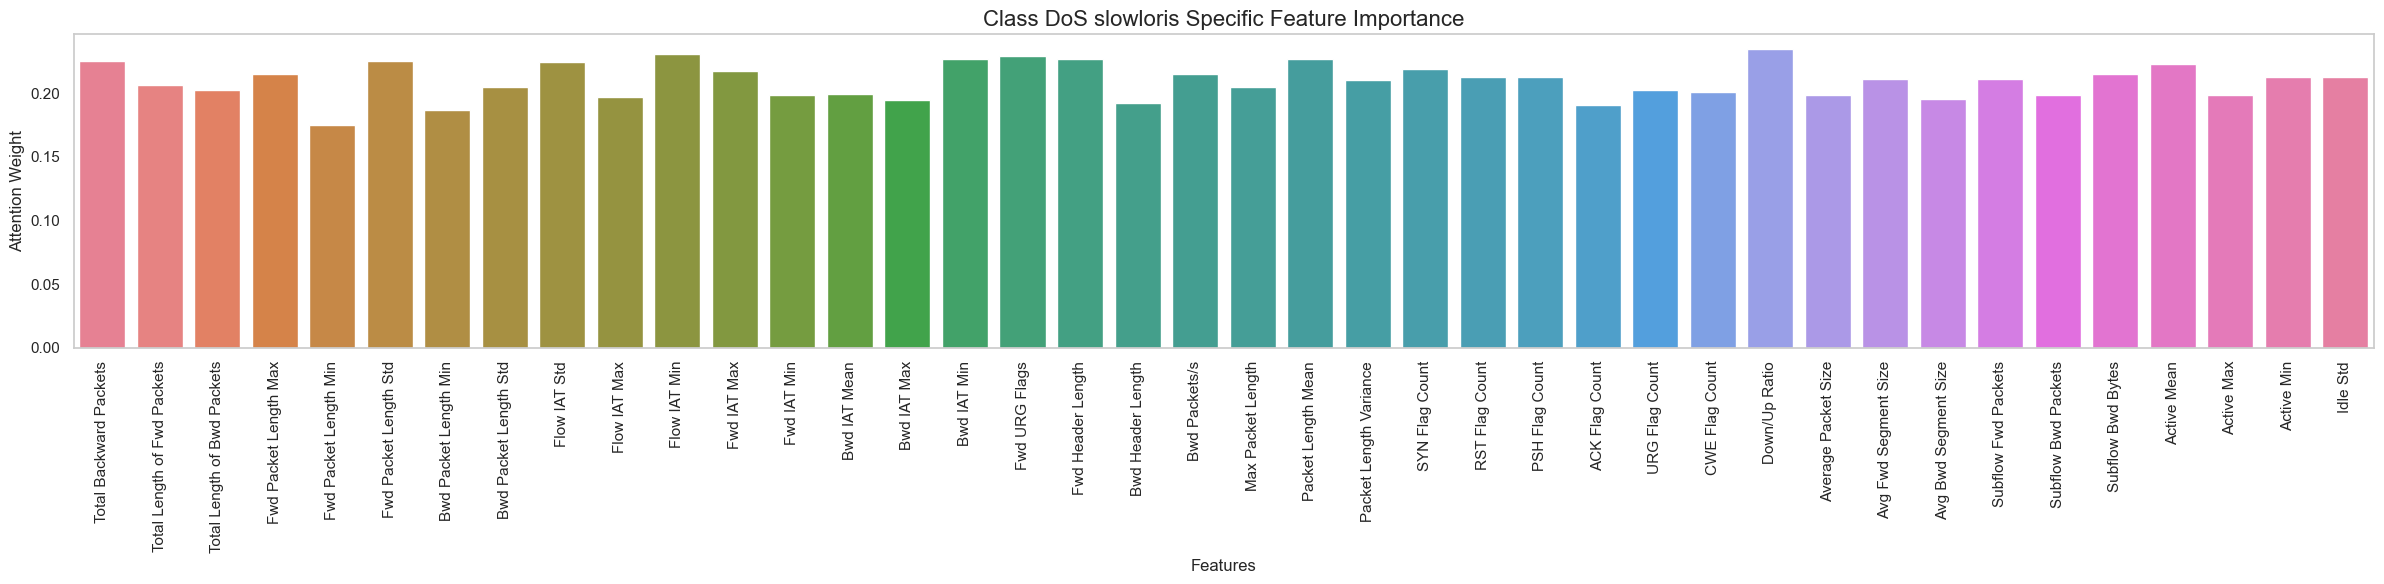

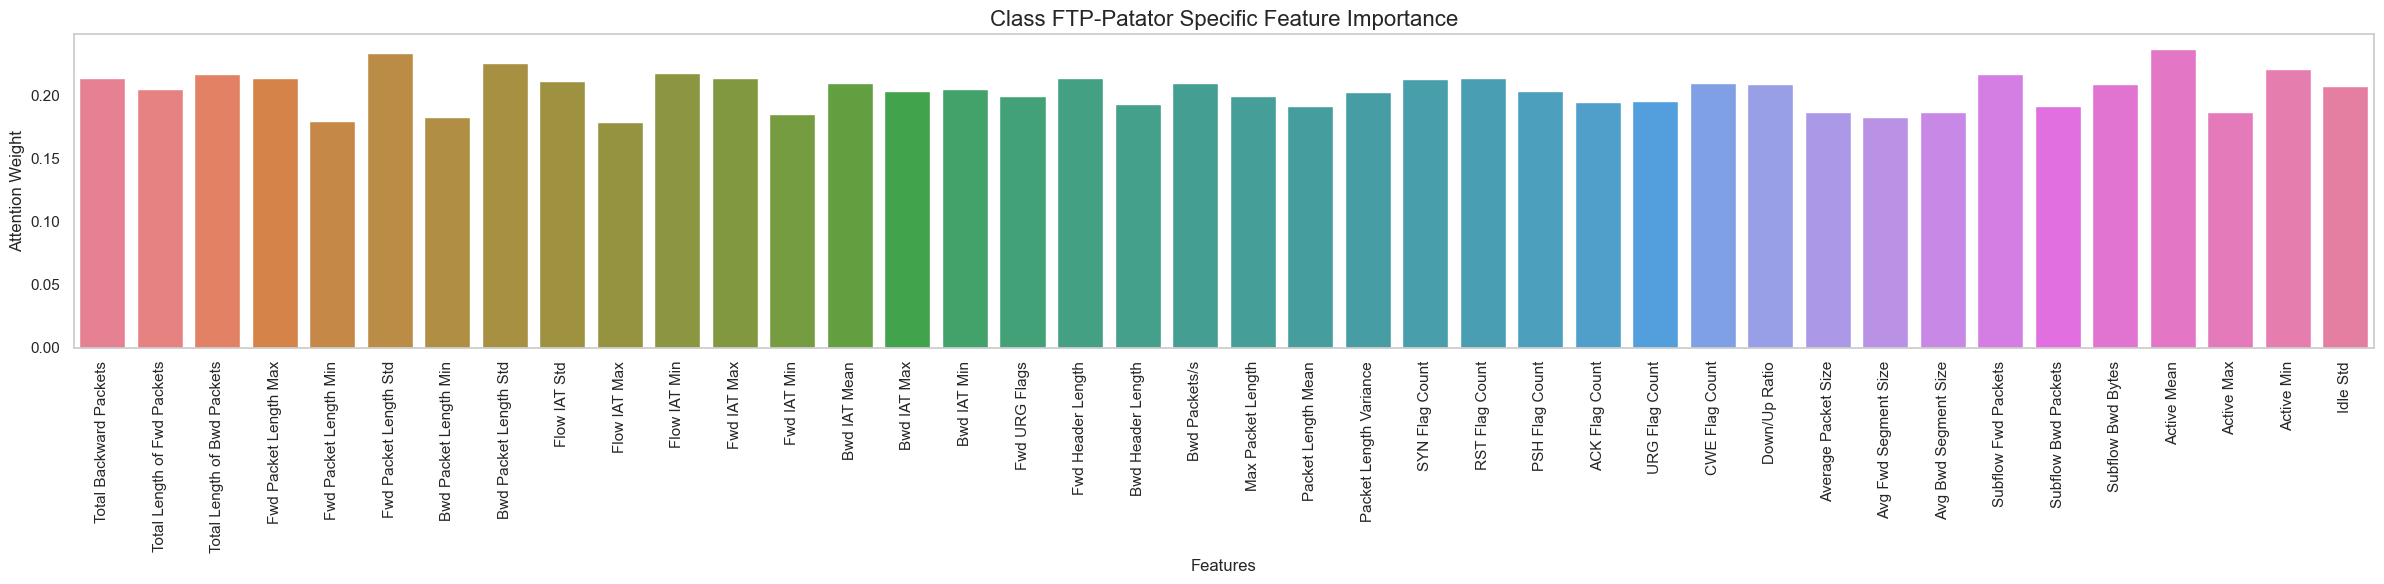

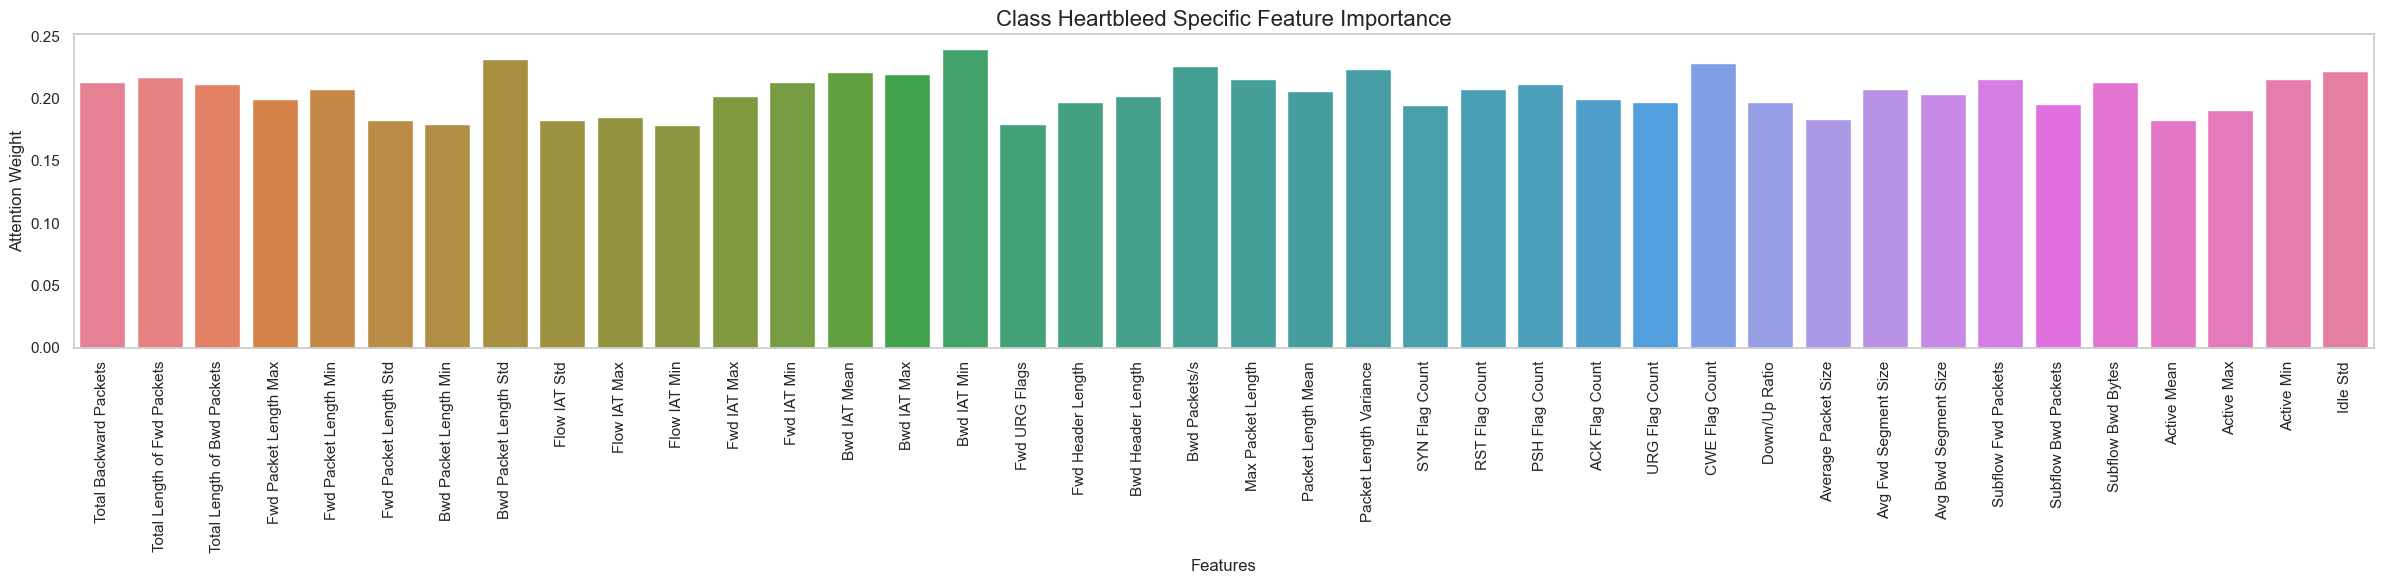

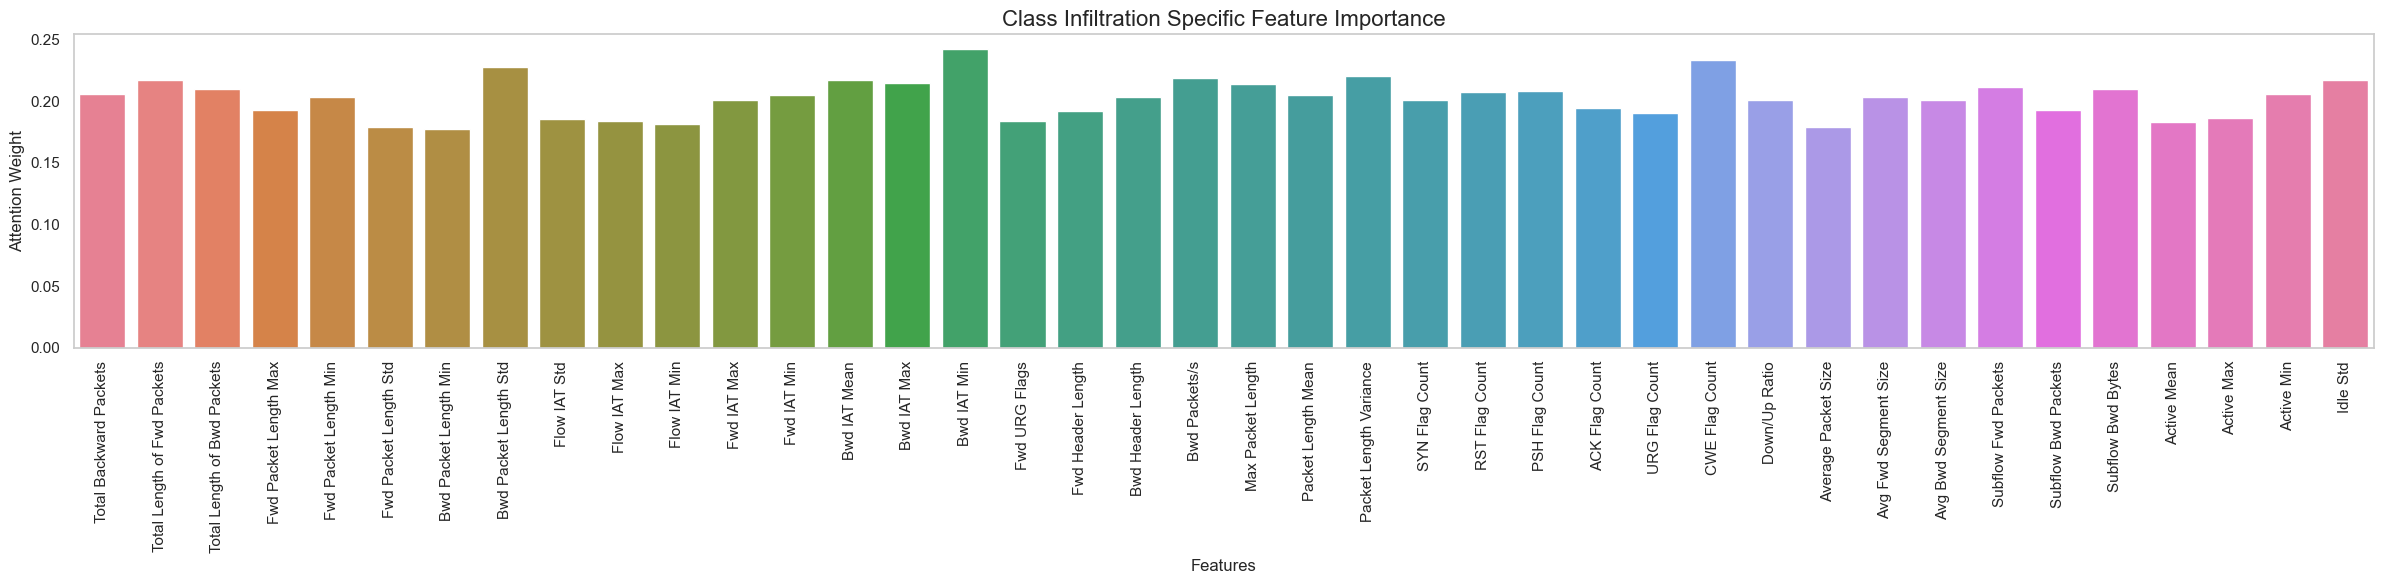

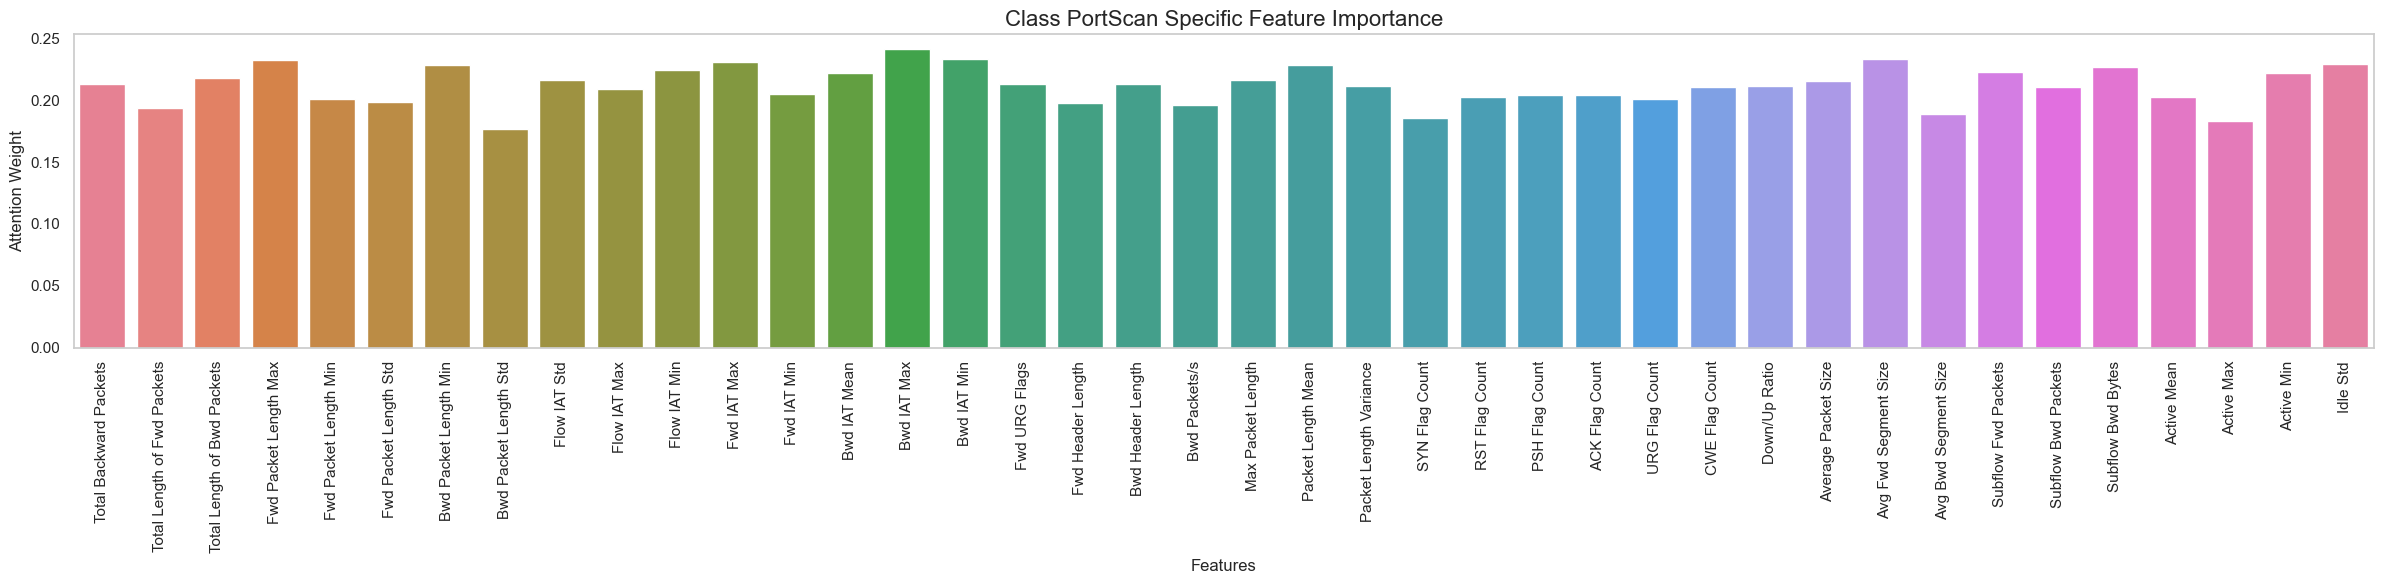

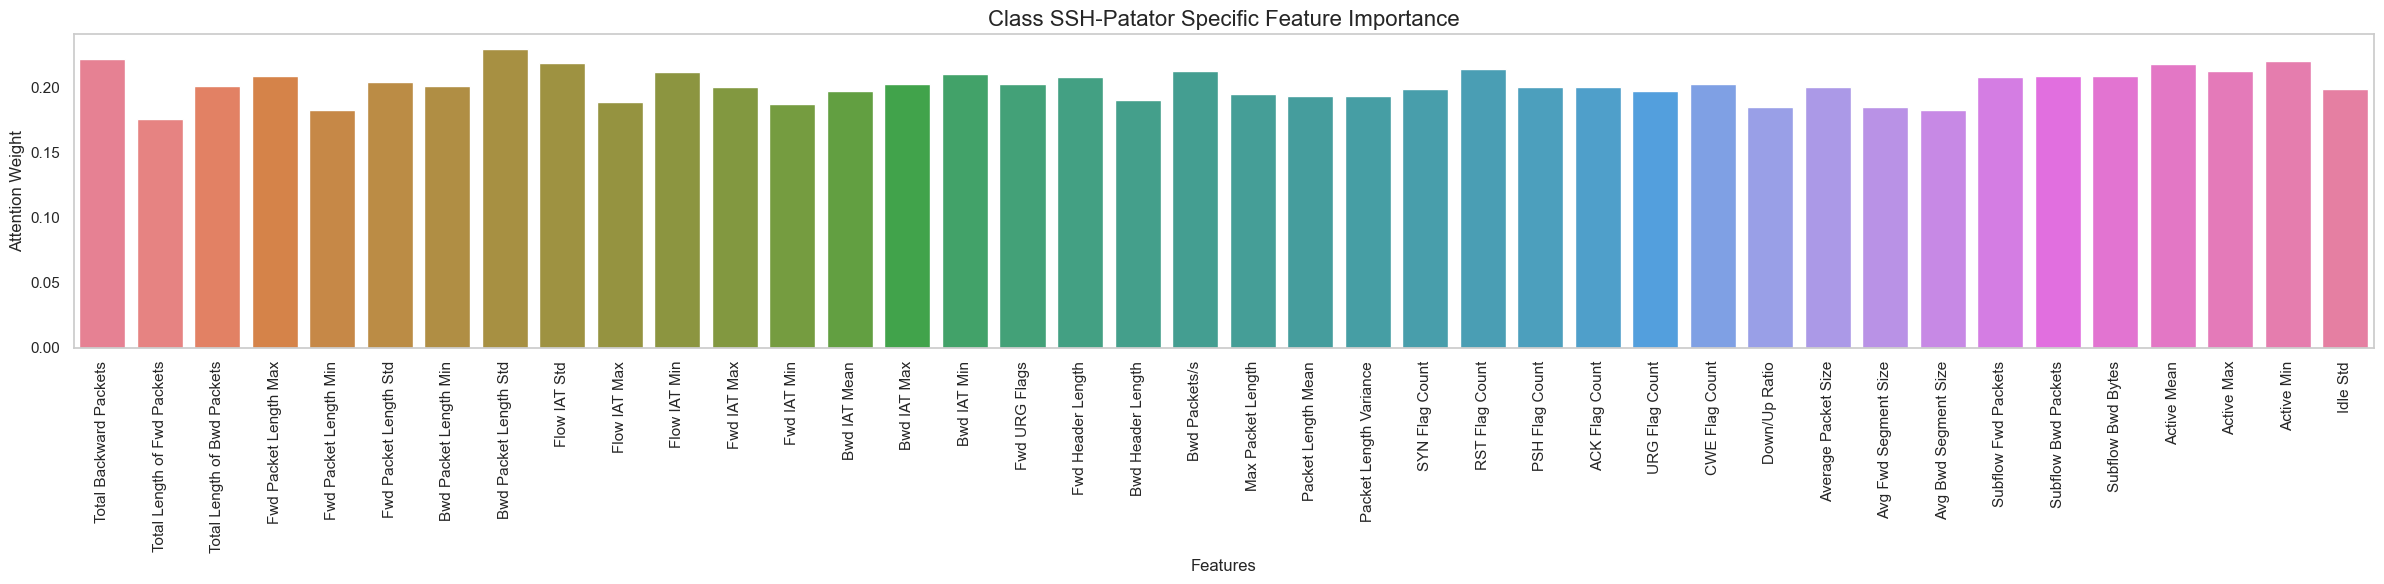

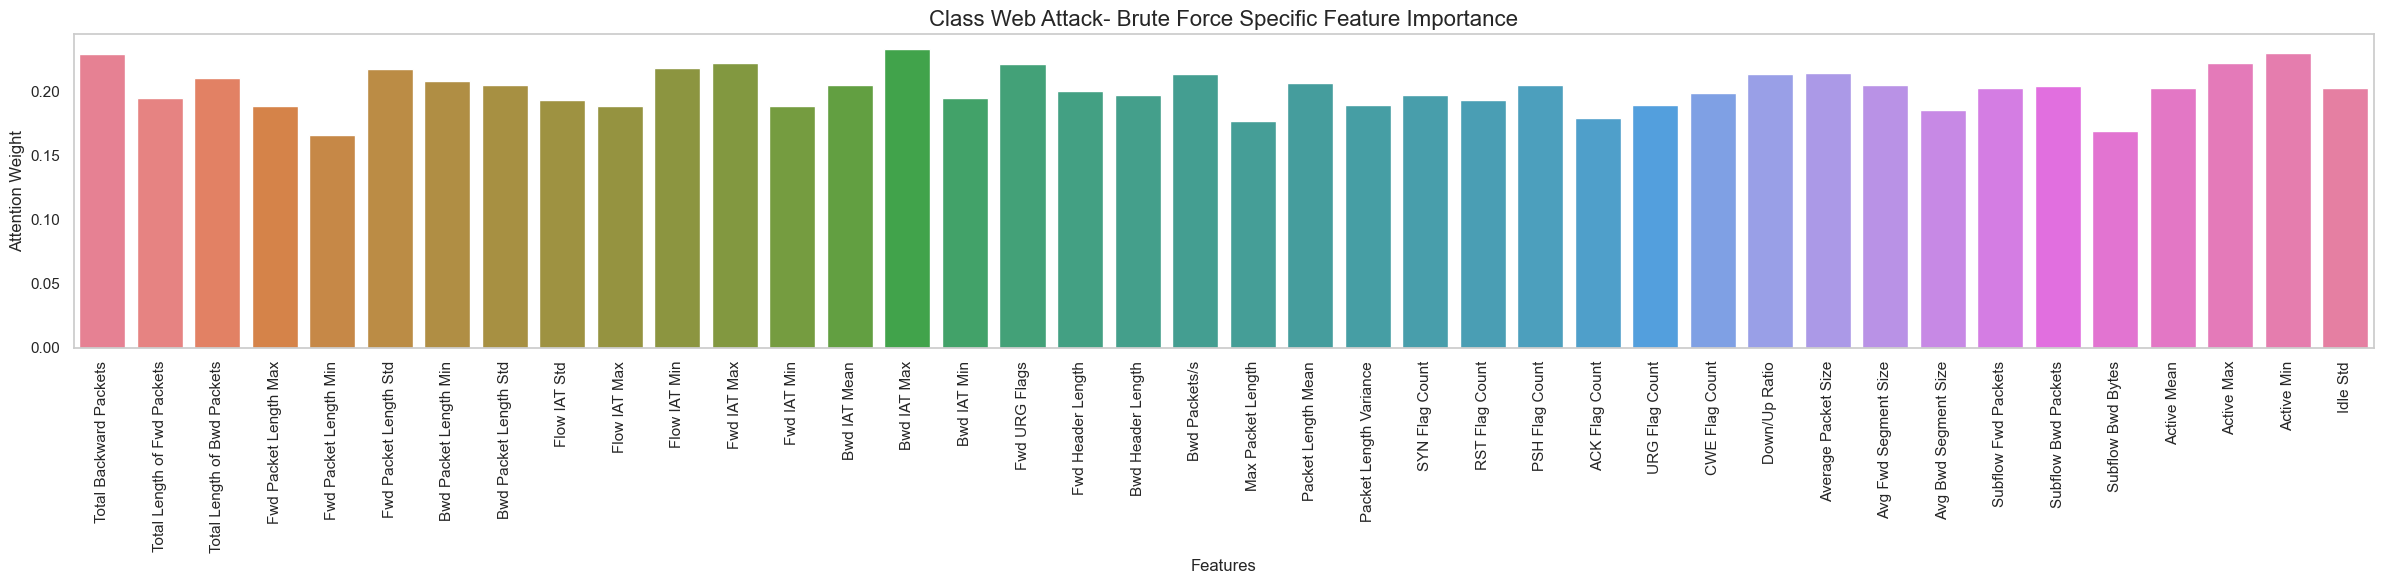

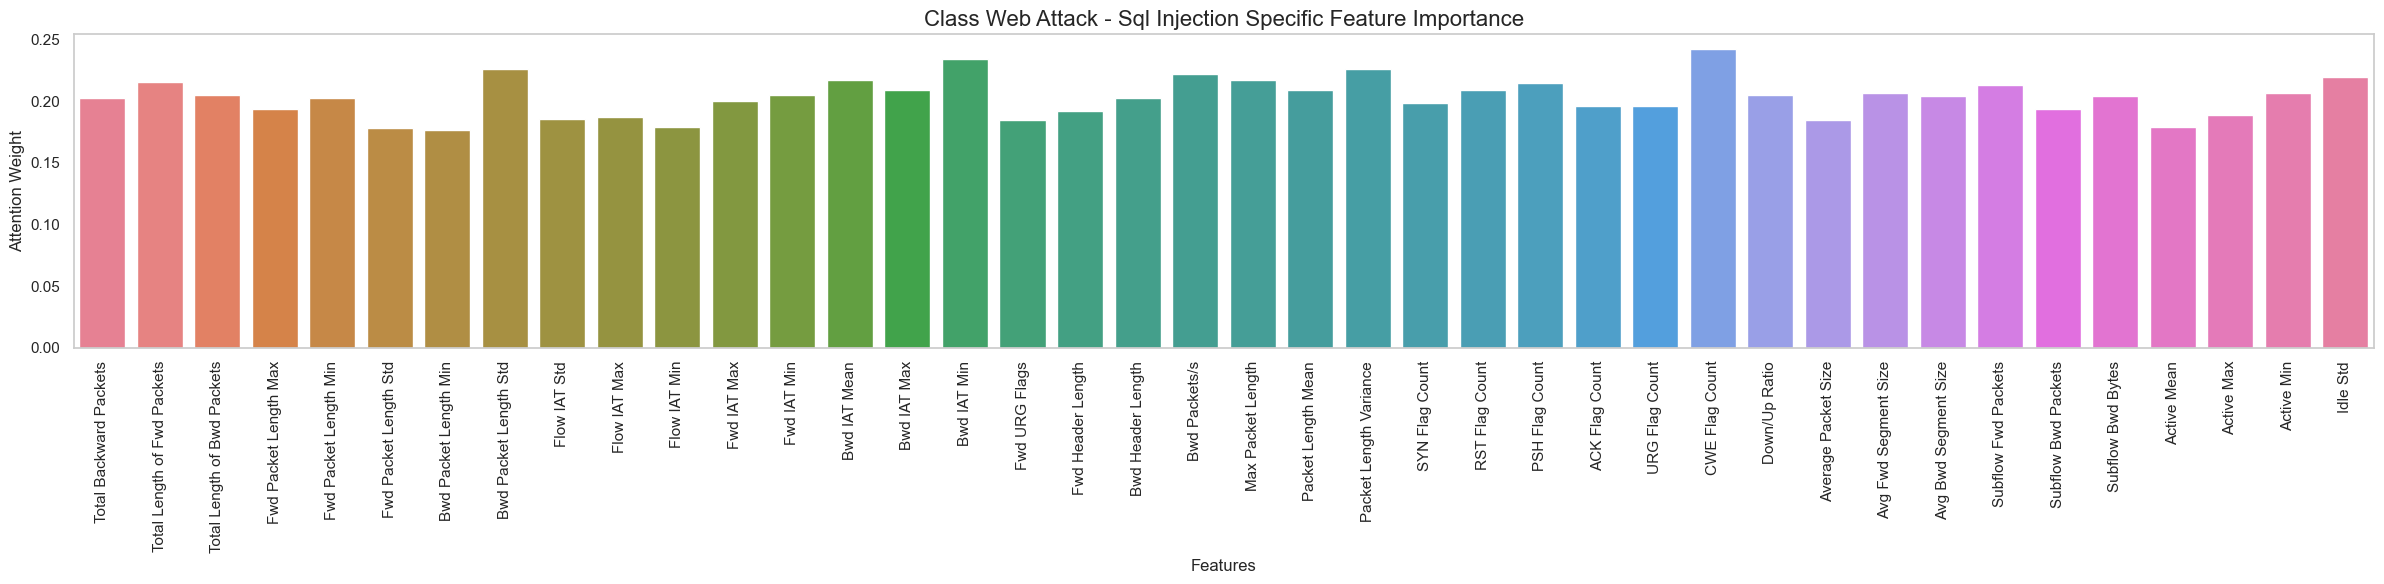

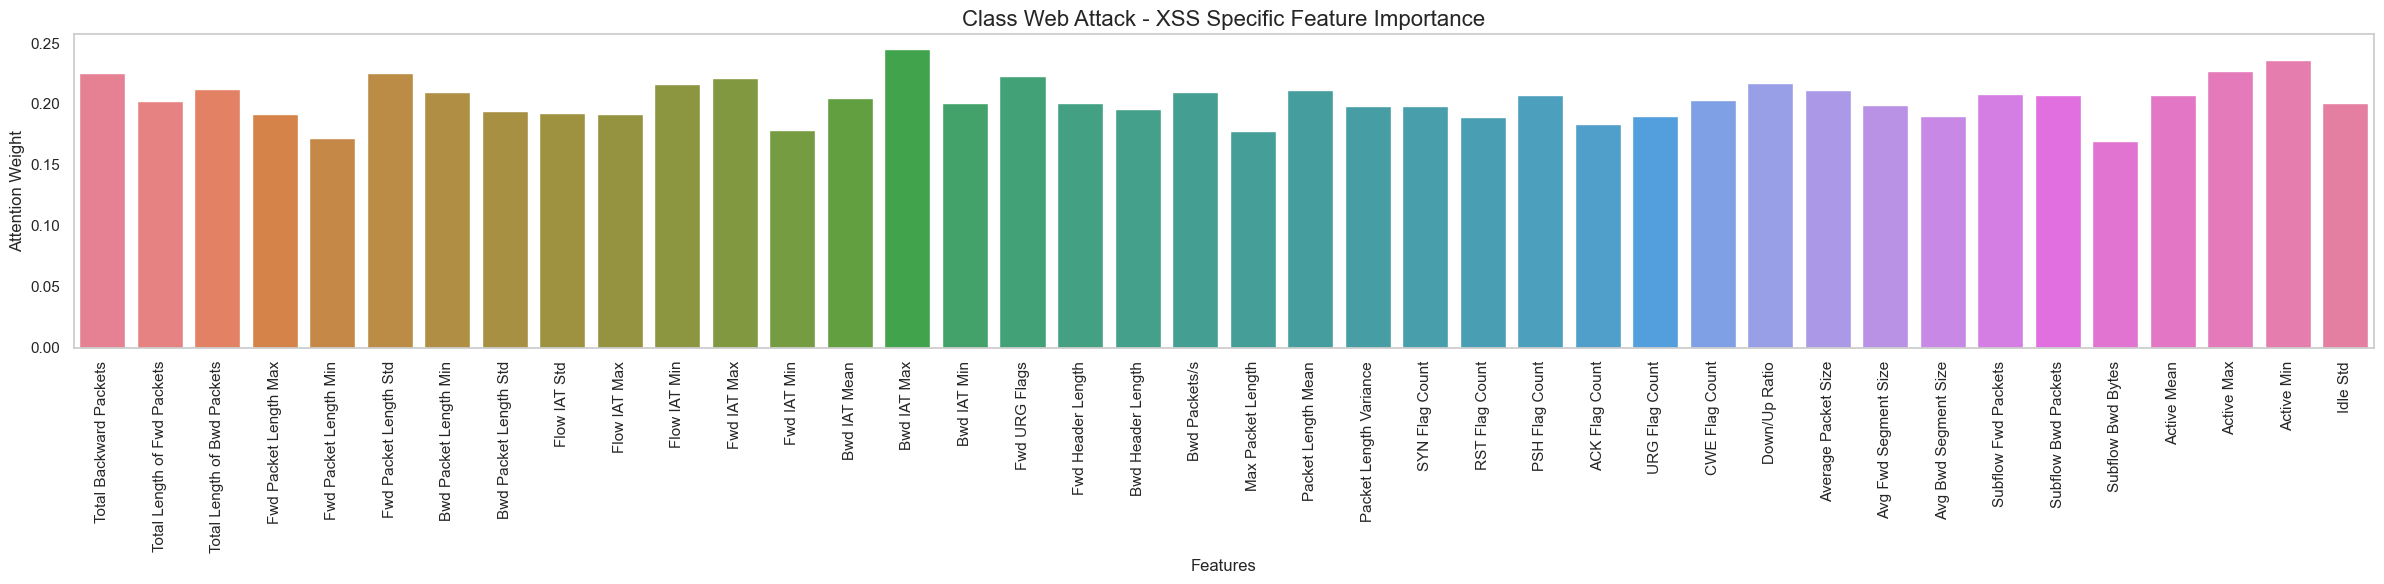

In [141]:
import numpy as np
import matplotlib.pyplot as plt


feature_names = [ 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max',
        'Fwd Packet Length Min', 'Fwd Packet Length Std', 'Bwd Packet Length Min', 'Bwd Packet Length Std', 'Flow IAT Std',
        'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Mean', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd URG Flags',
        'Fwd Header Length', 'Bwd Header Length', 'Bwd Packets/s', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Variance',
        'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'Down/Up Ratio',
        'Average Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Subflow Fwd Packets', 'Subflow Bwd Packets',
        'Subflow Bwd Bytes', 'Active Mean', 'Active Max', 'Active Min', 'Idle Std' ]

# Convert the feature names to indices
selected_feature_indices = [feature_names.index(name) for name in selected_feature_number.flatten()]

# Now you can slice the attention_weights_all using the indices

attention_weights_all = np.concatenate(attention_weights, axis=0)
attention_weights_all = attention_weights_all[:, selected_feature_indices]

y_true_all = np.concatenate(all_y_test, axis=0)
class_indices = np.argmax(y_true_all, axis=1)

# Compute average attention per class
num_classes = y_true_all.shape[1]
num_features = attention_weights_all.shape[1]

# Average attention per feature for each class
class_wise_attentions = np.zeros((num_classes, num_features))

for class_idx in range(num_classes):
    class_att_weights = attention_weights_all[class_indices == class_idx]
    class_wise_attentions[class_idx] = np.mean(class_att_weights, axis=0)

# Add your feature names

feature_names = [feature_names[i] for i in selected_feature_indices]

#  Add class names
class_names = ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest',
               'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan',
              'SSH-Patator', 'Web Attack- Brute Force', 'Web Attack - Sql Injection', 'Web Attack - XSS']
 
             
# Create a folder to save the plots (optional)
output_dir = "feature_importance_per_class_CICIDS2017"
os.makedirs(output_dir, exist_ok=True)
import seaborn as sns

colors = sns.color_palette("husl", num_features)
Set seaborn style
sns.set(style="whitegrid")

for class_idx in range(num_classes):
    plt.figure(figsize=(12, 5))
    plt.bar(range(num_features), class_wise_attentions[class_idx], color=colors)
    plt.xticks(ticks=np.arange(num_features), labels=feature_names, rotation=90)
    plt.xlabel('Features')
    plt.ylabel('Attention Weight')
    plt.title(f'Feature Attention for Class: {class_names[class_idx]}')
    plt.tight_layout()
    plt.grid(axis='y')
    plt.savefig(f"{output_dir}/{class_name}_feature_importance_multiclass_CICIDS2017.png", dpi=1200)
    plt.show()
      


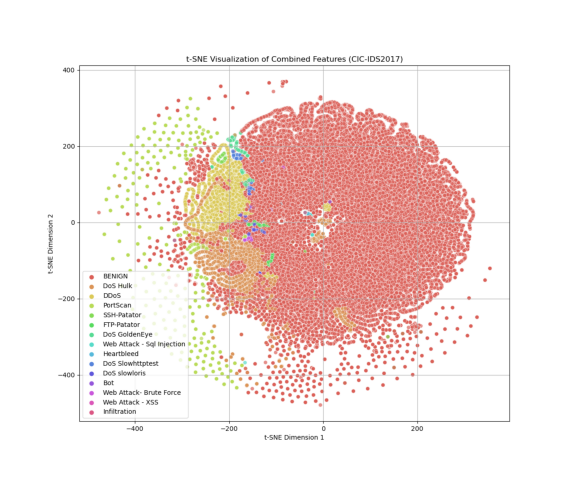

In [143]:
from sklearn.manifold import TSNE
# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X)

# Create a DataFrame for plotting
tsne_df = pd.DataFrame()
tsne_df['Dim1'] = X_tsne[:, 0]
tsne_df['Dim2'] = X_tsne[:, 1]
tsne_df['Label'] = y

# Plot
plt.figure(figsize=(12, 8))
sns.scatterplot(data=tsne_df, x='Dim1', y='Dim2', hue='Label', palette='tab10', alpha=0.7)
plt.title('t-SNE Visualization of Combined Features(CICIDS2017)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='lower left')
plt.tight_layout()
plt.show()

